In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('sales.csv')
data.head()

,Date,Sales
0,2023-01,200
1,2023-02,220
2,2023-03,250
3,2023-04,270
4,2023-05,300


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    20 non-null     object
 1   Sales   20 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 452.0+ bytes


In [4]:
data.isnull().sum()

,0
Date,0
Sales,0


In [5]:
data = data.dropna()

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    20 non-null     object
 1   Sales   20 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 452.0+ bytes


In [7]:
data = data.drop_duplicates()

In [8]:
data.head()

,Date,Sales
0,2023-01,200
1,2023-02,220
2,2023-03,250
3,2023-04,270
4,2023-05,300


In [9]:
data['Date'] = pd.to_datetime(data['Date'])

In [10]:
data['Month'] = data['Date'].dt.month

In [11]:
data.head()

,Date,Sales,Month
0,2023-01-01,200,1
1,2023-02-01,220,2
2,2023-03-01,250,3
3,2023-04-01,270,4
4,2023-05-01,300,5


In [12]:
from sklearn.linear_model import LinearRegression

In [13]:
X = data[['Month']]   # input
y = data['Sales']     # output

In [14]:
model = LinearRegression()

In [15]:
model.fit(X, y)

LinearRegression()

In [16]:
future_months = pd.DataFrame({'Month': [13, 14, 15]})

In [17]:
predictions = model.predict(future_months)
print(predictions)

[518.22233105 529.34867777 540.47502449]


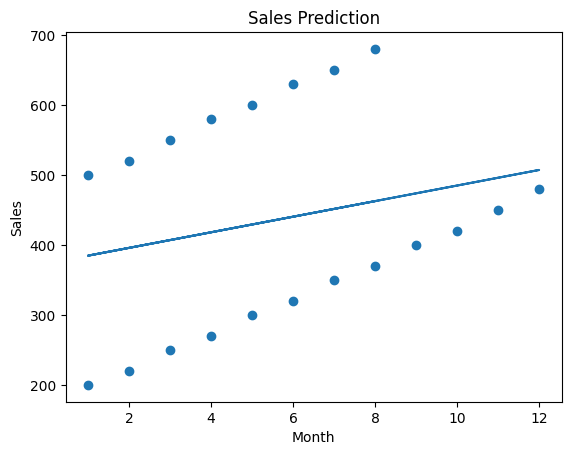

In [18]:
plt.scatter(X, y)                     # actual data points
plt.plot(X, model.predict(X))         # prediction line

plt.xlabel('Month')
plt.ylabel('Sales')
plt.title('Sales Prediction')

plt.show()

In [19]:
from sklearn.metrics import mean_squared_error

In [20]:
pred = model.predict(X)

In [21]:
mse = mean_squared_error(y, pred)
print("Error:", mse)

Error: 20067.047012732615
